In [5]:
import pandas as pd

traffic = pd.read_csv("/content/traffic_sensors.csv")

traffic.head()

,timestamp,device_id,location,traffic_count,status
0,2026-01-01 08:00:12,SENSOR_001,Zone_A,118.0,OK
1,2026-01-01 08:00:45,SENSOR_002,Zone_B,132.0,OK
2,2026-01-01 08:01:10,SENSOR_003,Zone_A,NaN,ERROR
3,2026-01-01 08:01:55,SENSOR_004,Zone_C,115.0,OK
4,2026-01-01 08:02:22,SENSOR_005,Zone_B,140.0,OK


In [6]:
print("Dataset shape:", traffic.shape)

print("\nColumns:")
print(traffic.columns.tolist())

Dataset shape: (50, 5)

Columns:
['timestamp', 'device_id', 'location', 'traffic_count', 'status']


In [7]:
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      50 non-null     object 
 1   device_id      50 non-null     object 
 2   location       50 non-null     object 
 3   traffic_count  40 non-null     float64
 4   status         50 non-null     object 
dtypes: float64(1), object(4)
memory usage: 2.1+ KB


In [8]:
weather = pd.read_csv("/content/weather_station.csv")

weather.head()

,timestamp,device_id,location,temperature,humidity,wind_speed,precipitation,status
0,2026-01-01 08:00:05,WS_001,Zone_A,30.2,71.0,5.2,0.0,OK
1,2026-01-01 08:00:40,WS_002,Zone_B,29.8,69.0,4.8,0.0,OK
2,2026-01-01 08:01:15,WS_003,Zone_C,NaN,72.0,5.5,0.1,ERROR
3,2026-01-01 08:01:50,WS_004,Zone_A,30.5,70.0,5.0,0.0,OK
4,2026-01-01 08:02:25,WS_005,Zone_B,30.1,NaN,4.9,0.0,ERROR


In [9]:
print("Shape:", weather.shape)

print("\nColumns:")
print(weather.columns.tolist())

weather.info()

Shape: (40, 8)

Columns:
['timestamp', 'device_id', 'location', 'temperature', 'humidity', 'wind_speed', 'precipitation', 'status']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      40 non-null     object 
 1   device_id      40 non-null     object 
 2   location       40 non-null     object 
 3   temperature    36 non-null     float64
 4   humidity       38 non-null     float64
 5   wind_speed     39 non-null     float64
 6   precipitation  40 non-null     float64
 7   status         40 non-null     object 
dtypes: float64(4), object(4)
memory usage: 2.6+ KB


In [10]:
traffic["timestamp"] = pd.to_datetime(traffic["timestamp"])

traffic["traffic_count"] = pd.to_numeric(
    traffic["traffic_count"],
    errors="coerce"
)

print("Missing traffic counts:")
print(traffic["traffic_count"].isnull().sum())

Missing traffic counts:
10


In [11]:
traffic["traffic_count"] = traffic["traffic_count"].fillna(
    traffic["traffic_count"].median()
)

print("Missing values after cleaning:")
print(traffic["traffic_count"].isnull().sum())

Missing values after cleaning:
0


In [12]:
traffic["Average_Speed"] = (
    60 - (traffic["traffic_count"] / traffic["traffic_count"].max()) * 40
)

traffic["Average_Speed"] = traffic["Average_Speed"].round(2)

traffic[["traffic_count", "Average_Speed"]].head()

,traffic_count,Average_Speed
0,118.0,27.45
1,132.0,23.59
2,127.5,24.83
3,115.0,28.28
4,140.0,21.38


In [13]:
traffic["Road_Occupancy"] = (
    traffic["traffic_count"] / traffic["traffic_count"].max() * 100
)

traffic["Road_Occupancy"] = traffic["Road_Occupancy"].round(2)

traffic[["traffic_count", "Road_Occupancy"]].head()

,traffic_count,Road_Occupancy
0,118.0,81.38
1,132.0,91.03
2,127.5,87.93
3,115.0,79.31
4,140.0,96.55


In [14]:
traffic["Junction_ID"] = traffic["location"]

traffic[["location", "Junction_ID"]].head()

,location,Junction_ID
0,Zone_A,Zone_A
1,Zone_B,Zone_B
2,Zone_A,Zone_A
3,Zone_C,Zone_C
4,Zone_B,Zone_B


In [15]:
traffic["Signal_Status"] = pd.cut(
    traffic["traffic_count"],
    bins=[-np.inf, 300, 600, np.inf],
    labels=["Green", "Yellow", "Red"]
)

traffic[["traffic_count", "Signal_Status"]].head()

,traffic_count,Signal_Status
0,118.0,Green
1,132.0,Green
2,127.5,Green
3,115.0,Green
4,140.0,Green


In [16]:
traffic.head()

,timestamp,device_id,location,traffic_count,status,Average_Speed,Road_Occupancy,Junction_ID,Signal_Status
0,2026-01-01 08:00:12,SENSOR_001,Zone_A,118.0,OK,27.45,81.38,Zone_A,Green
1,2026-01-01 08:00:45,SENSOR_002,Zone_B,132.0,OK,23.59,91.03,Zone_B,Green
2,2026-01-01 08:01:10,SENSOR_003,Zone_A,127.5,ERROR,24.83,87.93,Zone_A,Green
3,2026-01-01 08:01:55,SENSOR_004,Zone_C,115.0,OK,28.28,79.31,Zone_C,Green
4,2026-01-01 08:02:22,SENSOR_005,Zone_B,140.0,OK,21.38,96.55,Zone_B,Green


In [17]:
traffic.columns

Index(['timestamp', 'device_id', 'location', 'traffic_count', 'status',
       'Average_Speed', 'Road_Occupancy', 'Junction_ID', 'Signal_Status'],
      dtype='object')

In [18]:
weather["timestamp"] = pd.to_datetime(weather["timestamp"])

weather.head()

,timestamp,device_id,location,temperature,humidity,wind_speed,precipitation,status
0,2026-01-01 08:00:05,WS_001,Zone_A,30.2,71.0,5.2,0.0,OK
1,2026-01-01 08:00:40,WS_002,Zone_B,29.8,69.0,4.8,0.0,OK
2,2026-01-01 08:01:15,WS_003,Zone_C,NaN,72.0,5.5,0.1,ERROR
3,2026-01-01 08:01:50,WS_004,Zone_A,30.5,70.0,5.0,0.0,OK
4,2026-01-01 08:02:25,WS_005,Zone_B,30.1,NaN,4.9,0.0,ERROR


In [20]:
print(weather.columns.tolist())

['timestamp', 'device_id', 'location', 'temperature', 'humidity', 'wind_speed', 'precipitation', 'status']


In [21]:
weather["Weather"] = np.where(
    weather["precipitation"] > 0,
    "Rainy",
    "Clear"
)

weather[["timestamp", "precipitation", "Weather"]].head()

,timestamp,precipitation,Weather
0,2026-01-01 08:00:05,0.0,Clear
1,2026-01-01 08:00:40,0.0,Clear
2,2026-01-01 08:01:15,0.1,Rainy
3,2026-01-01 08:01:50,0.0,Clear
4,2026-01-01 08:02:25,0.0,Clear


In [22]:
df = pd.merge(
    traffic,
    weather[[
        "timestamp",
        "location",
        "temperature",
        "humidity",
        "wind_speed",
        "precipitation",
        "Weather"
    ]],
    on=["timestamp", "location"],
    how="left"
)

print("Final dataset shape:", df.shape)
df.head()

Final dataset shape: (50, 14)


,timestamp,device_id,location,traffic_count,status,Average_Speed,Road_Occupancy,Junction_ID,Signal_Status,temperature,humidity,wind_speed,precipitation,Weather
0,2026-01-01 08:00:12,SENSOR_001,Zone_A,118.0,OK,27.45,81.38,Zone_A,Green,NaN,NaN,NaN,NaN,NaN
1,2026-01-01 08:00:45,SENSOR_002,Zone_B,132.0,OK,23.59,91.03,Zone_B,Green,NaN,NaN,NaN,NaN,NaN
2,2026-01-01 08:01:10,SENSOR_003,Zone_A,127.5,ERROR,24.83,87.93,Zone_A,Green,NaN,NaN,NaN,NaN,NaN
3,2026-01-01 08:01:55,SENSOR_004,Zone_C,115.0,OK,28.28,79.31,Zone_C,Green,NaN,NaN,NaN,NaN,NaN
4,2026-01-01 08:02:22,SENSOR_005,Zone_B,140.0,OK,21.38,96.55,Zone_B,Green,NaN,NaN,NaN,NaN,NaN


In [23]:
print(df.columns.tolist())

['timestamp', 'device_id', 'location', 'traffic_count', 'status', 'Average_Speed', 'Road_Occupancy', 'Junction_ID', 'Signal_Status', 'temperature', 'humidity', 'wind_speed', 'precipitation', 'Weather']


In [24]:
df["Date"] = df["timestamp"].dt.date

# Select a few dates as event days
unique_dates = sorted(df["Date"].unique())

event_dates = unique_dates[:3]

df["Event_Status"] = np.where(
    df["Date"].isin(event_dates),
    "Event",
    "Normal"
)

df[["timestamp", "Event_Status"]].head(10)

,timestamp,Event_Status
0,2026-01-01 08:00:12,Event
1,2026-01-01 08:00:45,Event
2,2026-01-01 08:01:10,Event
3,2026-01-01 08:01:55,Event
4,2026-01-01 08:02:22,Event
5,2026-01-01 08:02:50,Event
6,2026-01-01 08:03:15,Event
7,2026-01-01 08:03:45,Event
8,2026-01-01 08:04:12,Event
9,2026-01-01 08:04:55,Event


In [25]:
print(df["Event_Status"].value_counts())


Event_Status
Event    50
Name: count, dtype: int64


In [26]:
final_df = df[[
    "timestamp",
    "Junction_ID",
    "traffic_count",
    "Average_Speed",
    "Road_Occupancy",
    "Signal_Status",
    "Weather",
    "Event_Status"
]].copy()

In [27]:
final_df.rename(
    columns={
        "timestamp": "Timestamp",
        "traffic_count": "Vehicle_Count"
    },
    inplace=True
)

In [28]:
final_df.head()

,Timestamp,Junction_ID,Vehicle_Count,Average_Speed,Road_Occupancy,Signal_Status,Weather,Event_Status
0,2026-01-01 08:00:12,Zone_A,118.0,27.45,81.38,Green,NaN,Event
1,2026-01-01 08:00:45,Zone_B,132.0,23.59,91.03,Green,NaN,Event
2,2026-01-01 08:01:10,Zone_A,127.5,24.83,87.93,Green,NaN,Event
3,2026-01-01 08:01:55,Zone_C,115.0,28.28,79.31,Green,NaN,Event
4,2026-01-01 08:02:22,Zone_B,140.0,21.38,96.55,Green,NaN,Event


In [29]:
print(final_df.columns.tolist())

['Timestamp', 'Junction_ID', 'Vehicle_Count', 'Average_Speed', 'Road_Occupancy', 'Signal_Status', 'Weather', 'Event_Status']


In [30]:
final_df.to_csv(
    "smart_city_traffic_final.csv",
    index=False
)

print("Final dataset saved successfully!")

Final dataset saved successfully!


In [31]:
print(final_df.columns.tolist())
print(final_df.shape)

['Timestamp', 'Junction_ID', 'Vehicle_Count', 'Average_Speed', 'Road_Occupancy', 'Signal_Status', 'Weather', 'Event_Status']
(50, 8)


In [32]:
print("Dataset Information:")
print(final_df.info())

print("\nMissing Values:")
print(final_df.isnull().sum())

print("\nDuplicate Rows:")
print(final_df.duplicated().sum())

print("\nBasic Statistics:")
display(final_df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Timestamp       50 non-null     datetime64[ns]
 1   Junction_ID     50 non-null     object        
 2   Vehicle_Count   50 non-null     float64       
 3   Average_Speed   50 non-null     float64       
 4   Road_Occupancy  50 non-null     float64       
 5   Signal_Status   50 non-null     category      
 6   Weather         0 non-null      object        
 7   Event_Status    50 non-null     object        
dtypes: category(1), datetime64[ns](1), float64(3), object(3)
memory usage: 3.0+ KB
None

Missing Values:
Timestamp          0
Junction_ID        0
Vehicle_Count      0
Average_Speed      0
Road_Occupancy     0
Signal_Status      0
Weather           50
Event_Status       0
dtype: int64

Duplicate Rows:
0

Basic Statistics:


,Timestamp,Vehicle_Count,Average_Speed,Road_Occupancy
count,50,50.000000,50.000000,50.000000
mean,2026-01-01 08:14:00.420000,128.500000,24.552200,88.621000
min,2026-01-01 08:00:12,115.000000,20.000000,79.310000
25%,2026-01-01 08:06:48.750000128,122.250000,23.170000,84.312500
50%,2026-01-01 08:13:57.500000,127.500000,24.830000,87.930000
75%,2026-01-01 08:21:06.249999872,133.500000,26.272500,92.065000
max,2026-01-01 08:28:15,145.000000,28.280000,100.000000
std,NaN,8.050859,2.220718,5.551303


In [33]:
print("Number of Junctions:", final_df["Junction_ID"].nunique())

print("\nJunctions:")
print(final_df["Junction_ID"].value_counts())

print("\nTime Range:")
print("Start:", final_df["Timestamp"].min())
print("End:", final_df["Timestamp"].max())

Number of Junctions: 3

Junctions:
Junction_ID
Zone_A    20
Zone_B    15
Zone_C    15
Name: count, dtype: int64

Time Range:
Start: 2026-01-01 08:00:12
End: 2026-01-01 08:28:15


In [34]:
# Create Weather from precipitation data

df["Weather"] = np.where(
    df["precipitation"].fillna(0) > 0,
    "Rainy",
    "Clear"
)

# Update final dataset
final_df["Weather"] = df["Weather"]

print("Weather values:")
print(final_df["Weather"].value_counts())

print("\nMissing Weather values:")
print(final_df["Weather"].isnull().sum())

Weather values:
Weather
Clear    50
Name: count, dtype: int64

Missing Weather values:
0


In [35]:
display(final_df.head())

,Timestamp,Junction_ID,Vehicle_Count,Average_Speed,Road_Occupancy,Signal_Status,Weather,Event_Status
0,2026-01-01 08:00:12,Zone_A,118.0,27.45,81.38,Green,Clear,Event
1,2026-01-01 08:00:45,Zone_B,132.0,23.59,91.03,Green,Clear,Event
2,2026-01-01 08:01:10,Zone_A,127.5,24.83,87.93,Green,Clear,Event
3,2026-01-01 08:01:55,Zone_C,115.0,28.28,79.31,Green,Clear,Event
4,2026-01-01 08:02:22,Zone_B,140.0,21.38,96.55,Green,Clear,Event


In [36]:
print("Missing values:")
print(final_df.isnull().sum())

print("\nDuplicate rows:")
print(final_df.duplicated().sum())

print("\nData types:")
print(final_df.dtypes)

Missing values:
Timestamp         0
Junction_ID       0
Vehicle_Count     0
Average_Speed     0
Road_Occupancy    0
Signal_Status     0
Weather           0
Event_Status      0
dtype: int64

Duplicate rows:
0

Data types:
Timestamp         datetime64[ns]
Junction_ID               object
Vehicle_Count            float64
Average_Speed            float64
Road_Occupancy           float64
Signal_Status           category
Weather                   object
Event_Status              object
dtype: object


In [37]:
final_df.to_csv(
    "smart_city_traffic_cleaned.csv",
    index=False
)

print("✅ Cleaned dataset saved successfully!")

✅ Cleaned dataset saved successfully!


In [38]:
# Create time-based features

final_df["Hour"] = final_df["Timestamp"].dt.hour
final_df["Day"] = final_df["Timestamp"].dt.day_name()
final_df["Date"] = final_df["Timestamp"].dt.date

print("Time features created successfully!")

display(
    final_df[
        ["Timestamp", "Hour", "Day", "Date", "Junction_ID", "Vehicle_Count"]
    ].head()
)

Time features created successfully!


,Timestamp,Hour,Day,Date,Junction_ID,Vehicle_Count
0,2026-01-01 08:00:12,8,Thursday,2026-01-01,Zone_A,118.0
1,2026-01-01 08:00:45,8,Thursday,2026-01-01,Zone_B,132.0
2,2026-01-01 08:01:10,8,Thursday,2026-01-01,Zone_A,127.5
3,2026-01-01 08:01:55,8,Thursday,2026-01-01,Zone_C,115.0
4,2026-01-01 08:02:22,8,Thursday,2026-01-01,Zone_B,140.0


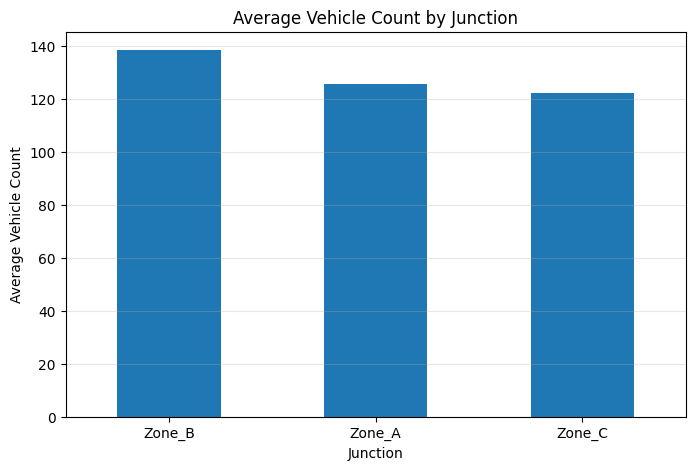

In [39]:
import matplotlib.pyplot as plt

junction_traffic = (
    final_df.groupby("Junction_ID")["Vehicle_Count"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

junction_traffic.plot(kind="bar")

plt.title("Average Vehicle Count by Junction")
plt.xlabel("Junction")
plt.ylabel("Average Vehicle Count")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [40]:
print("Average Vehicle Count by Junction:")
print(junction_traffic)

Average Vehicle Count by Junction:
Junction_ID
Zone_B    138.566667
Zone_A    125.700000
Zone_C    122.166667
Name: Vehicle_Count, dtype: float64


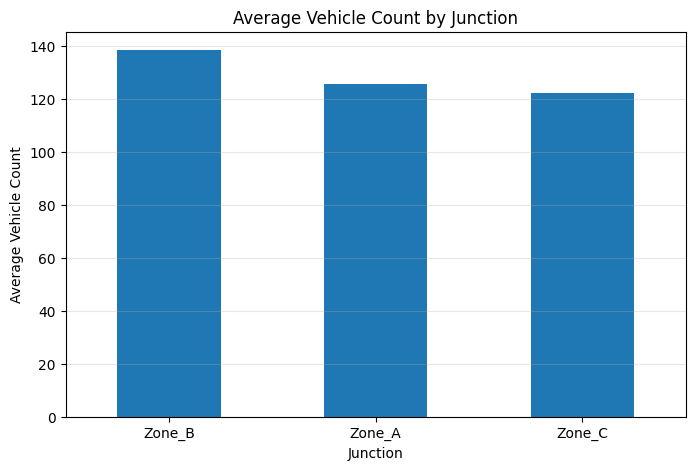

Average Vehicle Count by Junction:
Junction_ID
Zone_B    138.566667
Zone_A    125.700000
Zone_C    122.166667
Name: Vehicle_Count, dtype: float64


In [41]:
import matplotlib.pyplot as plt

junction_traffic = (
    final_df.groupby("Junction_ID")["Vehicle_Count"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

junction_traffic.plot(kind="bar")

plt.title("Average Vehicle Count by Junction")
plt.xlabel("Junction")
plt.ylabel("Average Vehicle Count")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

print("Average Vehicle Count by Junction:")
print(junction_traffic)

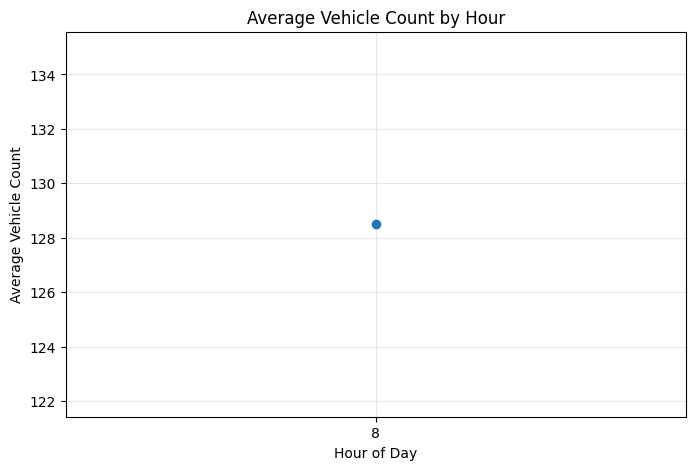

Average Vehicle Count by Hour:
Hour
8    128.5
Name: Vehicle_Count, dtype: float64


In [42]:
# Average vehicle count by hour

hourly_traffic = (
    final_df.groupby("Hour")["Vehicle_Count"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(8, 5))

hourly_traffic.plot(
    kind="line",
    marker="o"
)

plt.title("Average Vehicle Count by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Vehicle Count")
plt.xticks(hourly_traffic.index)
plt.grid(True, alpha=0.3)

plt.show()

print("Average Vehicle Count by Hour:")
print(hourly_traffic)

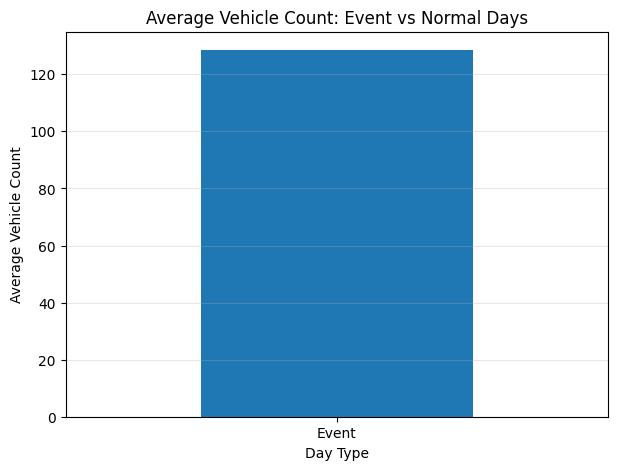

Average Vehicle Count:
Event_Status
Event    128.5
Name: Vehicle_Count, dtype: float64


In [43]:
# Average traffic on Event vs Normal days

event_traffic = (
    final_df.groupby("Event_Status")["Vehicle_Count"]
    .mean()
)

plt.figure(figsize=(7, 5))

event_traffic.plot(kind="bar")

plt.title("Average Vehicle Count: Event vs Normal Days")
plt.xlabel("Day Type")
plt.ylabel("Average Vehicle Count")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

print("Average Vehicle Count:")
print(event_traffic)

In [44]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

final_df[[
    "Vehicle_Norm",
    "Speed_Norm",
    "Occupancy_Norm"
]] = scaler.fit_transform(
    final_df[
        ["Vehicle_Count", "Average_Speed", "Road_Occupancy"]
    ]
)

final_df["Congestion_Score"] = (
    final_df["Vehicle_Norm"]
    + (1 - final_df["Speed_Norm"])
    + final_df["Occupancy_Norm"]
) / 3

print("Congestion score created successfully!")

display(
    final_df[
        ["Junction_ID", "Vehicle_Count", "Average_Speed",
         "Road_Occupancy", "Congestion_Score"]
    ].head()
)

Congestion score created successfully!


,Junction_ID,Vehicle_Count,Average_Speed,Road_Occupancy,Congestion_Score
0,Zone_A,118.0,27.45,81.38,0.100097
1,Zone_B,132.0,23.59,91.03,0.566516
2,Zone_A,127.5,24.83,87.93,0.416653
3,Zone_C,115.0,28.28,79.31,0.000000
4,Zone_B,140.0,21.38,96.55,0.833306


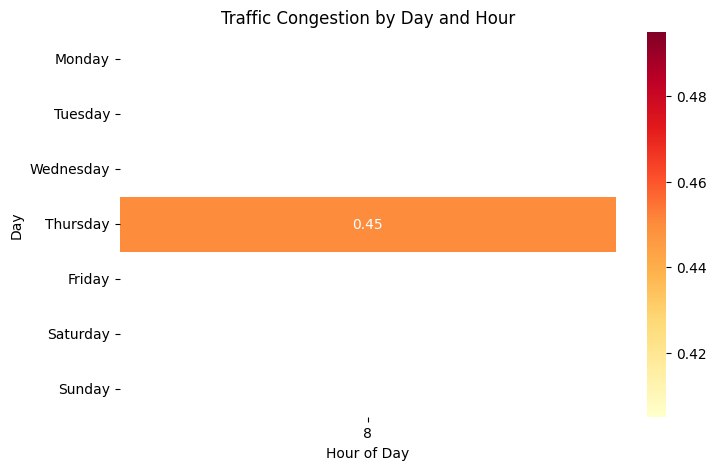

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = final_df.pivot_table(
    index="Day",
    columns="Hour",
    values="Congestion_Score",
    aggfunc="mean"
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(8, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd"
)

plt.title("Traffic Congestion by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day")

plt.show()

In [46]:
# Average congestion score by junction

hotspots = (
    final_df.groupby("Junction_ID")["Congestion_Score"]
    .mean()
    .sort_values(ascending=False)
)

print("Congestion Score by Junction:")
print(hotspots)

Congestion Score by Junction:
Junction_ID
Zone_B    0.785537
Zone_A    0.356793
Zone_C    0.239008
Name: Congestion_Score, dtype: float64


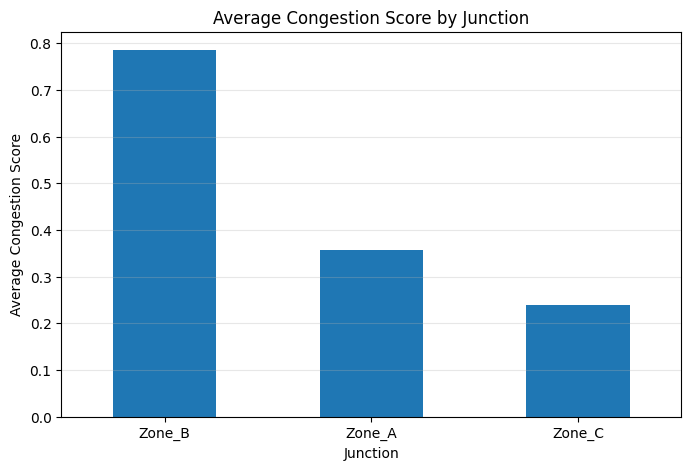

In [47]:
plt.figure(figsize=(8, 5))

hotspots.plot(kind="bar")

plt.title("Average Congestion Score by Junction")
plt.xlabel("Junction")
plt.ylabel("Average Congestion Score")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [48]:
hotspot_details = (
    final_df.groupby("Junction_ID")
    .agg({
        "Vehicle_Count": "mean",
        "Average_Speed": "mean",
        "Road_Occupancy": "mean",
        "Congestion_Score": "mean"
    })
    .sort_values("Congestion_Score", ascending=False)
)

display(hotspot_details)

,Vehicle_Count,Average_Speed,Road_Occupancy,Congestion_Score
Junction_ID,,,,
Zone_B,138.566667,21.775333,95.561333,0.785537
Zone_A,125.700000,25.324500,86.691500,0.356793
Zone_C,122.166667,26.299333,84.253333,0.239008


In [49]:
# Define high congestion as the top 25% of congestion scores

threshold = final_df["Congestion_Score"].quantile(0.75)

final_df["High_Congestion"] = (
    final_df["Congestion_Score"] >= threshold
).astype(int)

print("Congestion threshold:", round(threshold, 3))

print("\nTarget distribution:")
print(final_df["High_Congestion"].value_counts())

display(
    final_df[
        ["Junction_ID", "Hour", "Weather",
         "Event_Status", "Congestion_Score",
         "High_Congestion"]
    ].head(10)
)

Congestion threshold: 0.617

Target distribution:
High_Congestion
0    37
1    13
Name: count, dtype: int64


,Junction_ID,Hour,Weather,Event_Status,Congestion_Score,High_Congestion
0,Zone_A,8,Clear,Event,0.100097,0
1,Zone_B,8,Clear,Event,0.566516,0
2,Zone_A,8,Clear,Event,0.416653,0
3,Zone_C,8,Clear,Event,0.000000,0
4,Zone_B,8,Clear,Event,0.833306,1
5,Zone_A,8,Clear,Event,0.333387,0
6,Zone_C,8,Clear,Event,0.416653,0
7,Zone_B,8,Clear,Event,0.766710,1
8,Zone_A,8,Clear,Event,0.399984,0
9,Zone_C,8,Clear,Event,0.166694,0


In [50]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Select features
X = final_df[
    [
        "Junction_ID",
        "Hour",
        "Day",
        "Weather",
        "Event_Status"
    ]
].copy()

y = final_df["High_Congestion"]

# Convert categorical columns into numerical columns
X = pd.get_dummies(
    X,
    columns=[
        "Junction_ID",
        "Day",
        "Weather",
        "Event_Status"
    ],
    drop_first=True
)

print("Features prepared successfully!")
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())

Features prepared successfully!
Feature shape: (50, 3)
Target shape: (50,)


,Hour,Junction_ID_Zone_B,Junction_ID_Zone_C
0,8,False,False
1,8,True,False
2,8,False,False
3,8,False,True
4,8,True,False


In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training samples: 40
Testing samples: 10

Training target distribution:
High_Congestion
0    30
1    10
Name: count, dtype: int64

Testing target distribution:
High_Congestion
0    7
1    3
Name: count, dtype: int64


In [52]:
# Create Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

# Train the model
rf_model.fit(X_train, y_train)

print("✅ Random Forest model trained successfully!")

✅ Random Forest model trained successfully!


In [53]:
# Predict on test data

y_pred = rf_model.predict(X_test)

print("Actual values:")
print(y_test.values)

print("\nPredicted values:")
print(y_pred)

Actual values:
[0 0 0 0 0 1 0 1 0 1]

Predicted values:
[0 0 0 0 0 1 0 1 0 1]


In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Random Forest Model Evaluation")
print("--------------------------------")
print("Accuracy :", round(accuracy, 2))
print("Precision:", round(precision, 2))
print("Recall   :", round(recall, 2))
print("F1-Score :", round(f1, 2))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "High Congestion"],
    zero_division=0
))

Random Forest Model Evaluation
--------------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0

Classification Report:
                 precision    recall  f1-score   support

         Normal       1.00      1.00      1.00         7
High Congestion       1.00      1.00      1.00         3

       accuracy                           1.00        10
      macro avg       1.00      1.00      1.00        10
   weighted avg       1.00      1.00      1.00        10



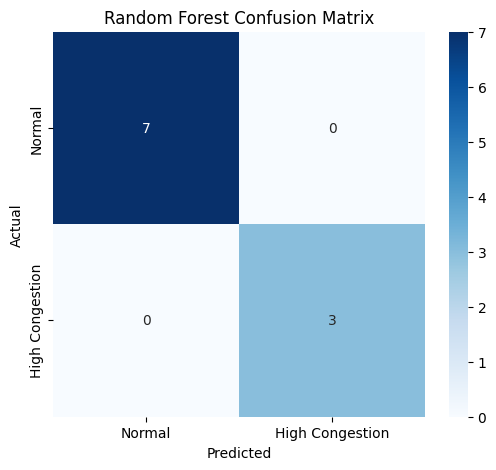

In [55]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "High Congestion"],
    yticklabels=["Normal", "High Congestion"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [56]:
# Get feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
1,Junction_ID_Zone_B,0.879511
2,Junction_ID_Zone_C,0.120489
0,Hour,0.000000


<Figure size 900x600 with 0 Axes>

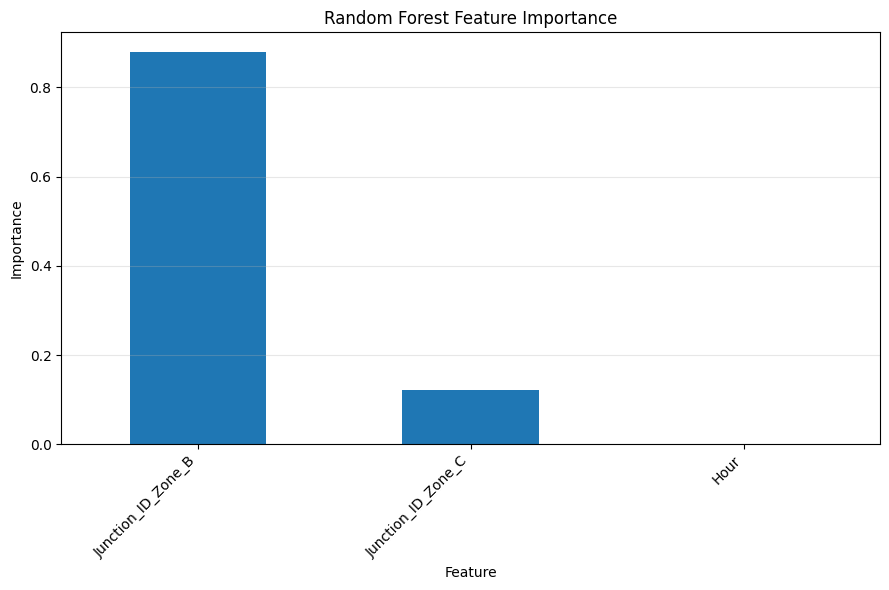

In [57]:
plt.figure(figsize=(9, 6))

feature_importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    legend=False,
    figsize=(9, 6)
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [58]:
print("===== SMART CITY TRAFFIC ANALYSIS =====\n")

# 1. Junction with highest traffic
highest_traffic_junction = junction_traffic.idxmax()
highest_traffic_value = junction_traffic.max()

print(
    f"1. {highest_traffic_junction} recorded the highest "
    f"average vehicle count of {highest_traffic_value:.2f}."
)

# 2. Junction with highest congestion
highest_congestion_junction = hotspots.idxmax()
highest_congestion_value = hotspots.max()

print(
    f"2. {highest_congestion_junction} had the highest "
    f"average congestion score of {highest_congestion_value:.3f}."
)

# 3. Peak observed hour
peak_hour = hourly_traffic.idxmax()
peak_hour_value = hourly_traffic.max()

print(
    f"3. The highest observed average traffic occurred at "
    f"{peak_hour}:00 with {peak_hour_value:.2f} vehicles."
)

# 4. Event vs normal comparison
if "Event" in event_traffic.index and "Normal" in event_traffic.index:
    event_value = event_traffic["Event"]
    normal_value = event_traffic["Normal"]

    print(
        f"4. Average traffic on Event days was {event_value:.2f}, "
        f"compared with {normal_value:.2f} on Normal days."
    )

# 5. High congestion records
high_count = final_df["High_Congestion"].sum()
total_count = len(final_df)

print(
    f"5. {high_count} out of {total_count} observations "
    f"were classified as high congestion."
)

# 6. Average speed
print(
    f"6. The overall average vehicle speed was "
    f"{final_df['Average_Speed'].mean():.2f}."
)

# 7. Average road occupancy
print(
    f"7. The overall average road occupancy was "
    f"{final_df['Road_Occupancy'].mean():.2f}%."
)

===== SMART CITY TRAFFIC ANALYSIS =====

1. Zone_B recorded the highest average vehicle count of 138.57.
2. Zone_B had the highest average congestion score of 0.786.
3. The highest observed average traffic occurred at 8:00 with 128.50 vehicles.
5. 13 out of 50 observations were classified as high congestion.
6. The overall average vehicle speed was 24.55.
7. The overall average road occupancy was 88.62%.


In [59]:
print("""
===== PRACTICAL ACTION PLAN =====

1. Monitor high-congestion junctions more frequently.
2. Adjust traffic signal timing during periods of higher traffic.
3. Use real-time traffic counts to detect increasing congestion.
4. Consider alternate routes when a junction shows sustained congestion.
5. Include weather and event information in future traffic monitoring.
6. Collect larger datasets covering multiple days and time periods.
7. Retrain the Random Forest model when more real-world data is available.
""")


===== PRACTICAL ACTION PLAN =====

1. Monitor high-congestion junctions more frequently.
2. Adjust traffic signal timing during periods of higher traffic.
3. Use real-time traffic counts to detect increasing congestion.
4. Consider alternate routes when a junction shows sustained congestion.
5. Include weather and event information in future traffic monitoring.
6. Collect larger datasets covering multiple days and time periods.
7. Retrain the Random Forest model when more real-world data is available.



In [60]:
# Save the final analyzed dataset

final_df.to_csv(
    "smart_city_traffic_final_analysis.csv",
    index=False
)

print("✅ Final dataset saved successfully!")
print("File: smart_city_traffic_final_analysis.csv")
print("Shape:", final_df.shape)

✅ Final dataset saved successfully!
File: smart_city_traffic_final_analysis.csv
Shape: (50, 16)


In [61]:
# Check the final saved dataset

check_df = pd.read_csv("smart_city_traffic_final_analysis.csv")

print("Rows:", check_df.shape[0])
print("Columns:", check_df.shape[1])

display(check_df.head())

Rows: 50
Columns: 16


,Timestamp,Junction_ID,Vehicle_Count,Average_Speed,Road_Occupancy,Signal_Status,Weather,Event_Status,Hour,Day,Date,Vehicle_Norm,Speed_Norm,Occupancy_Norm,Congestion_Score,High_Congestion
0,2026-01-01 08:00:12,Zone_A,118.0,27.45,81.38,Green,Clear,Event,8,Thursday,2026-01-01,0.100000,0.899758,0.100048,0.100097,0
1,2026-01-01 08:00:45,Zone_B,132.0,23.59,91.03,Green,Clear,Event,8,Thursday,2026-01-01,0.566667,0.433575,0.566457,0.566516,0
2,2026-01-01 08:01:10,Zone_A,127.5,24.83,87.93,Green,Clear,Event,8,Thursday,2026-01-01,0.416667,0.583333,0.416626,0.416653,0
3,2026-01-01 08:01:55,Zone_C,115.0,28.28,79.31,Green,Clear,Event,8,Thursday,2026-01-01,0.000000,1.000000,0.000000,0.000000,0
4,2026-01-01 08:02:22,Zone_B,140.0,21.38,96.55,Green,Clear,Event,8,Thursday,2026-01-01,0.833333,0.166667,0.833253,0.833306,1
